In [1]:
#@title importing files/data
# File and system handling
import os
import sys

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

# Machine learning
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Suppress warnings
pd.options.mode.chained_assignment = None

# Download NLTK resources
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

# Download and load SpaCy model
!python -m spacy download en_core_web_md
text_to_nlp = spacy.load("en_core_web_md")

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vaishnavipalasamudrum/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vaishnavipalasamudrum/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vaishnavipalasamudrum/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/33.5 MB ? eta -:--:--

     ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/33.5 MB 17.4 MB/s eta 0:00:02

     ━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/33.5 MB 14.2 MB/s eta 0:00:02

     ━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/33.5 MB 16.7 MB/s eta 0:00:02

...

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 24.1/33.5 MB 18.2 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━ 28.0/33.5 MB 17.5 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━ 32.5/33.5 MB 17.9 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 16.8 MB/s  0:00:02


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [2]:
#@title import our data

# import from Google Cloud
!wget https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%201%20-%205/Session%203%20-%20NLP/yelp_final.csv

zsh:1: command not found: wget


# Data Exploration

First we read in the file containing the reviews and take a look at the data available to us.

In [3]:
# read data
yelp_full = pd.read_csv('yelp_final.csv')
yelp_full.head()

,business_id,stars,text,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,5,My wife took me here on my birthday for breakf...,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,5,I have no idea why some people give bad review...,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,_1QQZuf4zZOyFCvXc0o6Vg,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",uZetl9T0NcROGOyFfughhg,1,2,0
3,6ozycU1RpktNG2-1BroVtw,5,General Manager Scott Petello is a good egg!!!...,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0
4,zp713qNhx8d9KCJJnrw1xA,5,Drop what you're doing and drive here. After I...,wFweIWhv2fREZV_dYkz_1g,7,7,4


In [4]:
# keep the needed columns

needed_columns = ['text', 'stars']
yelp = yelp_full[needed_columns]
yelp.head()

,text,stars
0,My wife took me here on my birthday for breakf...,5
1,I have no idea why some people give bad review...,5
2,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",5
3,General Manager Scott Petello is a good egg!!!...,5
4,Drop what you're doing and drive here. After I...,5


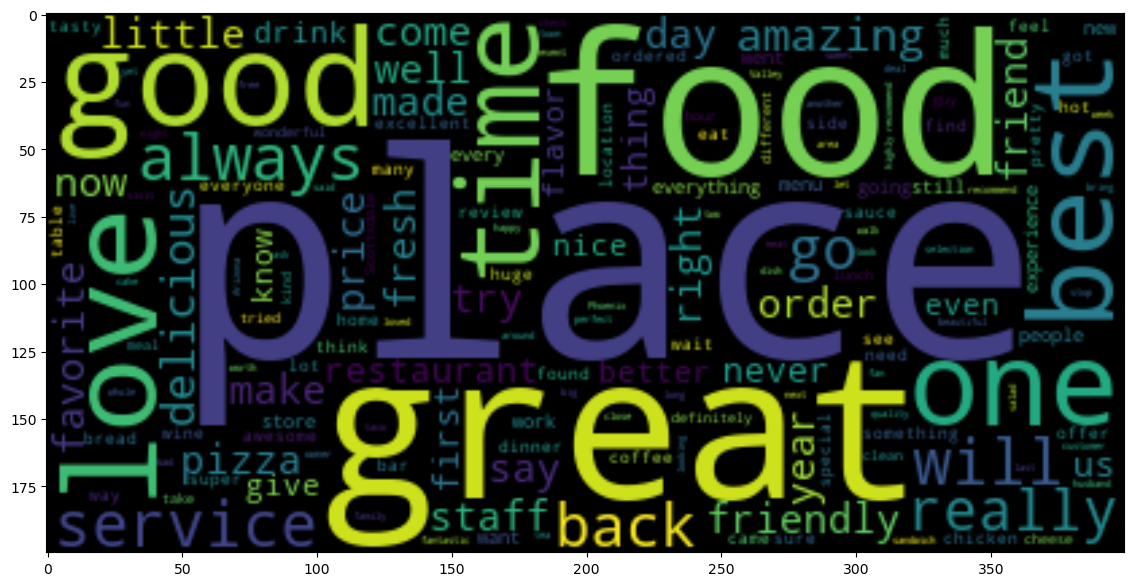

In [5]:
# generate word clouds for differently rated reviews
num_stars =  5
this_star_text = ''
for t in yelp[yelp['stars'] == num_stars]['text'].values:
    this_star_text += t + ' '

wordcloud = WordCloud()
wordcloud.generate_from_text(this_star_text)
plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation='bilinear')

##Prepare our data for ML to use logistic regression.

In [6]:
# reduce problem to a binary classification problem

def is_good_review(num_stars):
    return num_stars >= 4

# Change the stars column to either be 'good' or 'bad'.
yelp['is_good_review'] = yelp['stars'].apply(is_good_review)
yelp.head()

,text,stars,is_good_review
0,My wife took me here on my birthday for breakf...,5,True
1,I have no idea why some people give bad review...,5,True
2,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",5,True
3,General Manager Scott Petello is a good egg!!!...,5,True
4,Drop what you're doing and drive here. After I...,5,True


In [7]:
# input x
X_text = yelp['text']
# output y
y = yelp['is_good_review']

In [8]:
def tokenize(text):
    """
    Tokenizes text by removing stop words, punctuation, and pronouns, and returning lemmatized tokens.
    """
    return [
        token.lemma_
        for token in text_to_nlp(text)
        if not token.is_stop and token.lemma_ != '-PRON-' and not token.is_punct
    ]

In [9]:
bow_transformer = CountVectorizer(analyzer=tokenize, max_features=800).fit(X_text)

In [10]:
len(bow_transformer.vocabulary_)

800

In [11]:
# transform each review into a bag of words
X = bow_transformer.transform(X_text)

In [12]:
# see what X looks like by printing it out as a DataFrame
# 1000 reviews and how many times they used each words
pd.DataFrame(X.toarray())

,0,1,2,3,4,5,6,7,8,9,...,790,791,792,793,794,795,796,797,798,799
0,0,3,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,2,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,3,18,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,0,4,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
819,0,0,2,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
820,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
821,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


##**Logistic Regression** machine learning model.

In [13]:
# setting aside testing and training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

### Baseline: how well would a naive guess do?

Before trusting the logistic regression's accuracy, it's worth checking what a trivial model achieves. Yelp reviews skew positive, so a classifier that always predicts "good" will already look reasonably accurate. This baseline tells us how much signal the model is actually picking up beyond that class imbalance.

In [14]:
# baseline: always predict the majority class
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy='most_frequent', random_state=101)
baseline.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline.predict(X_test))
print(f"Baseline (majority class) accuracy: {baseline_accuracy:.3f}")

Baseline (majority class) accuracy: 0.685


In [15]:
logistic_model = LogisticRegression()

# train the model

logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
#Enter a review to see your model's classification
example_review = "This place was not good."
prediction = logistic_model.predict(bow_transformer.transform([example_review]))

if prediction:
  print ("This was a GOOD review!")
else:
  print ("This was a BAD review!")



This was a GOOD review!


In [17]:
# test the model

y_pred = logistic_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7151515151515152


### A closer look: confusion matrix and per-class metrics

Overall accuracy hides how the model performs on each class individually. Since "bad" reviews are the minority class, it's worth checking recall and precision for each label separately, not just the aggregate accuracy.

In [18]:
# confusion matrix: rows = true label, columns = predicted label
cm = confusion_matrix(y_test, y_pred, labels=[False, True])
cm_df = pd.DataFrame(
    cm,
    index=['actual: bad', 'actual: good'],
    columns=['predicted: bad', 'predicted: good']
)
cm_df

,predicted: bad,predicted: good
actual: bad,18,34
actual: good,13,100


In [19]:
# precision, recall, and f1-score broken out by class
print(classification_report(y_test, y_pred, target_names=['bad', 'good']))

              precision    recall  f1-score   support

         bad       0.58      0.35      0.43        52
        good       0.75      0.88      0.81       113

    accuracy                           0.72       165
   macro avg       0.66      0.62      0.62       165
weighted avg       0.69      0.72      0.69       165



## Results & Limitations

- **The model beats the naive baseline, but not by a wide margin.** Logistic regression scores higher than always predicting "good," but the gap is modest, which means a meaningful chunk of the reported accuracy comes from class imbalance rather than the model learning to distinguish sentiment.
- **The model struggles most on "bad" reviews.** Recall on the minority class is noticeably lower than on "good" reviews, so a large share of negative reviews get misclassified as positive. For a real moderation or alerting use case, this is the failure mode that matters most and the one this model handles worst.
- **The dataset is small and the feature space is narrow.** ~3,000 reviews and a 800-token bag-of-words vocabulary is enough for a proof of concept, but it limits how much nuance the model can capture.
- **Next steps to improve this:**
  - Address class imbalance directly (`class_weight='balanced'`, resampling, or a decision threshold tuned for recall on "bad" reviews).
  - Try TF-IDF weighting instead of raw counts, and compare against a non-linear model (e.g. random forest or gradient boosting).
  - Use k-fold cross-validation instead of a single train/test split to get a more reliable accuracy estimate.
  - Keep the original 1-5 star scale as an ordinal/multiclass target instead of collapsing to binary, to see how much information that simplification throws away.